# Simulación de un sistema de scoring de estados del sueño

#### TODO: Write in the docs about create a virtual env with those dependencies, we are using 3.11.0

In [ ]:
! pip install --upgrade pip
! pip install polars numpy seaborn matplotlib pyarrow pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 1.6 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.3 MB/s eta 0:00:002.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 2.1 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 1.7 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 1.5 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.2/326.2 kB 1.9 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.9 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.2 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 2.5 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 1.7 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

## Grafica primeros 1ooo datos de trains_series

Usando la librería `matplotlib` para graficar los primeros 1000 datos de `train_series`.

Usamos solo los datos `timestamp`, `anglez` y `enmo` de `train_series`.

In [46]:
n = 500_000 
df = pl.read_parquet('data/train_series.parquet', n_rows=n).to_pandas()
df.drop(columns=['series_id'], inplace=True)
df.head(5)

,step,timestamp,anglez,enmo
0,0,2018-08-14T15:30:00-0400,2.6367,0.0217
1,1,2018-08-14T15:30:05-0400,2.6368,0.0215
2,2,2018-08-14T15:30:10-0400,2.6370,0.0216
3,3,2018-08-14T15:30:15-0400,2.6368,0.0213
4,4,2018-08-14T15:30:20-0400,2.6368,0.0215


In [47]:
def get_hour(time):
    time = time.split('T')[1].split('-')[0].split(':')[0:2]
    return time[0] + ':' + time[1]
df['day'] = df['timestamp'].apply(lambda x: x.split('T')[0].split('-')[1] + '-' + x.split('T')[0].split('-')[2])
df['year'] = df['timestamp'].apply(lambda x: x.split('T')[0].split('-')[0])
df['timestamp'] = df['timestamp'].apply(lambda x: get_hour(x))
df


,step,timestamp,anglez,enmo,day,year
0,0,15:30,2.6367,0.0217,08-14,2018
1,1,15:30,2.6368,0.0215,08-14,2018
2,2,15:30,2.6370,0.0216,08-14,2018
3,3,15:30,2.6368,0.0213,08-14,2018
4,4,15:30,2.6368,0.0215,08-14,2018
...,...,...,...,...,...,...
499995,110115,20:56,4.6999,0.0007,06-06,2018
499996,110116,20:56,4.6999,0.0007,06-06,2018
499997,110117,20:56,4.6999,0.0007,06-06,2018
499998,110118,20:56,4.6999,0.0007,06-06,2018


In [17]:
timestamps = df['timestamp'].to_numpy()
anglez_values = df['anglez'].to_numpy()
enmo_values = df['enmo'].to_numpy()

# Algoritmo de Sadeh para calcular el puntaje de sueño

Usamos el algoritmo de Sadeh para calcular el puntaje de sueño. Este algoritmo toma en cuenta los siguientes parámetros:
- `timestamp`: la hora del registro.
- `anglez`: el ángulo de inclinación del cuerpo.
- `enmo`: la actividad física medida por el dispositivo.

y nos devuelve un puntaje de sueño entre 0 y 100 basado en estos parámetros.

In [18]:
def sadeh_algorithm_enhanced(enmo_data, anglez_data, window_size=11):
    """
    Implementación mejorada del algoritmo de Sadeh para scoring de sueño.
    Utiliza tanto ENMO (actividad) como Anglez (posición/orientación).
    
    El algoritmo combina:
    - ENMO: Actividad física/movimiento
    - Anglez: Cambios en la orientación corporal
    
    Fórmula modificada de Sadeh:
    Sleep Score = 7.601 - 0.065 * (mean_activity) - 1.08 * (nat_log_activity) 
                  - 0.056 * (std_activity) - 0.703 * (mean_activity_prev_6)
                  - 0.02 * (anglez_variability)  # Factor adicional para orientación
    
    Parámetros:
    - enmo_data: array de numpy con datos ENMO (actividad)
    - anglez_data: array de numpy con datos Anglez (orientación)
    - window_size: tamaño de la ventana para calcular estadísticas (default: 11 épocas)
    
    Retorna:
    - sleep_scores: array con los puntajes de sueño
    - sleep_wake_states: array binario (0=wake, 1=sleep)
    """
    
    # Combinar ENMO y variabilidad de Anglez como medida de actividad total
    # ENMO escalado + variabilidad del ángulo como indicador de movimiento
    scaled_enmo = enmo_data * 1000  # Escalar ENMO
    
    # Calcular la variabilidad de Anglez en ventanas para detectar cambios de posición
    anglez_variability = np.zeros(len(anglez_data))
    for i in range(len(anglez_data)):
        start_idx = max(0, i - 2)  # Ventana pequeña para detectar cambios
        end_idx = min(len(anglez_data), i + 3)
        window_anglez = anglez_data[start_idx:end_idx]
        anglez_variability[i] = np.std(window_anglez) if len(window_anglez) > 1 else 0
    
    # Combinar actividad: ENMO + variabilidad de orientación
    combined_activity = scaled_enmo + (anglez_variability * 50)  # Factor de escala para anglez
    
    # Inicializar arrays para resultados
    sleep_scores = np.zeros(len(combined_activity))
    sleep_wake_states = np.zeros(len(combined_activity))
    
    # Calcular para cada época
    for i in range(len(combined_activity)):
        
        # Definir ventana actual (centrada en i)
        half_window = window_size // 2
        start_idx = max(0, i - half_window)
        end_idx = min(len(combined_activity), i + half_window + 1)
        window_activity = combined_activity[start_idx:end_idx]
        
        # Calcular estadísticas de la ventana
        mean_activity_window = np.mean(window_activity)
        std_activity_window = np.std(window_activity)
        
        # Logaritmo natural (evitar log(0))
        nat_log_activity = np.log(mean_activity_window + 1)
        
        # Actividad promedio de los 6 minutos anteriores
        prev_start = max(0, i - 6)
        mean_activity_prev_6 = np.mean(combined_activity[prev_start:i+1]) if i > 0 else mean_activity_window
        
        # Factor adicional: variabilidad de Anglez en la ventana actual
        anglez_window = anglez_data[start_idx:end_idx]
        anglez_window_variability = np.std(anglez_window) if len(anglez_window) > 1 else 0
        
        # Aplicar fórmula de Sadeh modificada
        sleep_score = (7.601 - 0.065 * mean_activity_window - 1.08 * nat_log_activity 
                      - 0.056 * std_activity_window - 0.703 * mean_activity_prev_6
                      - 0.02 * anglez_window_variability)  # Factor Anglez
        
        sleep_scores[i] = sleep_score
        
        # Clasificar como sueño o vigilia 
        # Score < 0 = sleep, score >= 0 = wake
        sleep_wake_states[i] = 1 if sleep_score < 0 else 0
    
    return sleep_scores, sleep_wake_states, combined_activity, anglez_variability

# Aplicar el algoritmo de Sadeh mejorado usando ENMO y Anglez
print("Aplicando el algoritmo de Sadeh mejorado (ENMO + Anglez)...")
sleep_scores, sleep_states, combined_activity, anglez_variability = sadeh_algorithm_enhanced(enmo_values, anglez_values)

# Mostrar estadísticas
total_epochs = len(sleep_scores)
sleep_epochs = np.sum(sleep_states)
wake_epochs = total_epochs - sleep_epochs
sleep_efficiency = (sleep_epochs / total_epochs) * 100

print(f"Resultados del análisis de sueño (ENMO + Anglez):")
print(f"   Total de épocas analizadas: {total_epochs}")
print(f"   Épocas de sueño: {sleep_epochs} ({sleep_efficiency:.1f}%)")
print(f"   Épocas de vigilia: {wake_epochs} ({100-sleep_efficiency:.1f}%)")
print(f"   Puntaje promedio de sueño: {np.mean(sleep_scores):.2f}")
print(f"   Puntaje mínimo: {np.min(sleep_scores):.2f}")
print(f"   Puntaje máximo: {np.max(sleep_scores):.2f}")

print(f"\nAnalisis de componentes:")
print(f"   ENMO promedio: {np.mean(enmo_values):.4f}")
print(f"   Anglez variabilidad promedio: {np.mean(anglez_variability):.2f}")
print(f"   Actividad combinada promedio: {np.mean(combined_activity):.2f}")

Aplicando el algoritmo de Sadeh mejorado (ENMO + Anglez)...
Resultados del análisis de sueño (ENMO + Anglez):
   Total de épocas analizadas: 500000
   Épocas de sueño: 416505.0 (83.3%)
   Épocas de vigilia: 83495.0 (16.7%)
   Puntaje promedio de sueño: -237.82
   Puntaje mínimo: -2333.71
   Puntaje máximo: 7.60

Analisis de componentes:
   ENMO promedio: 0.0357
   Anglez variabilidad promedio: 5.34
   Actividad combinada promedio: 302.71


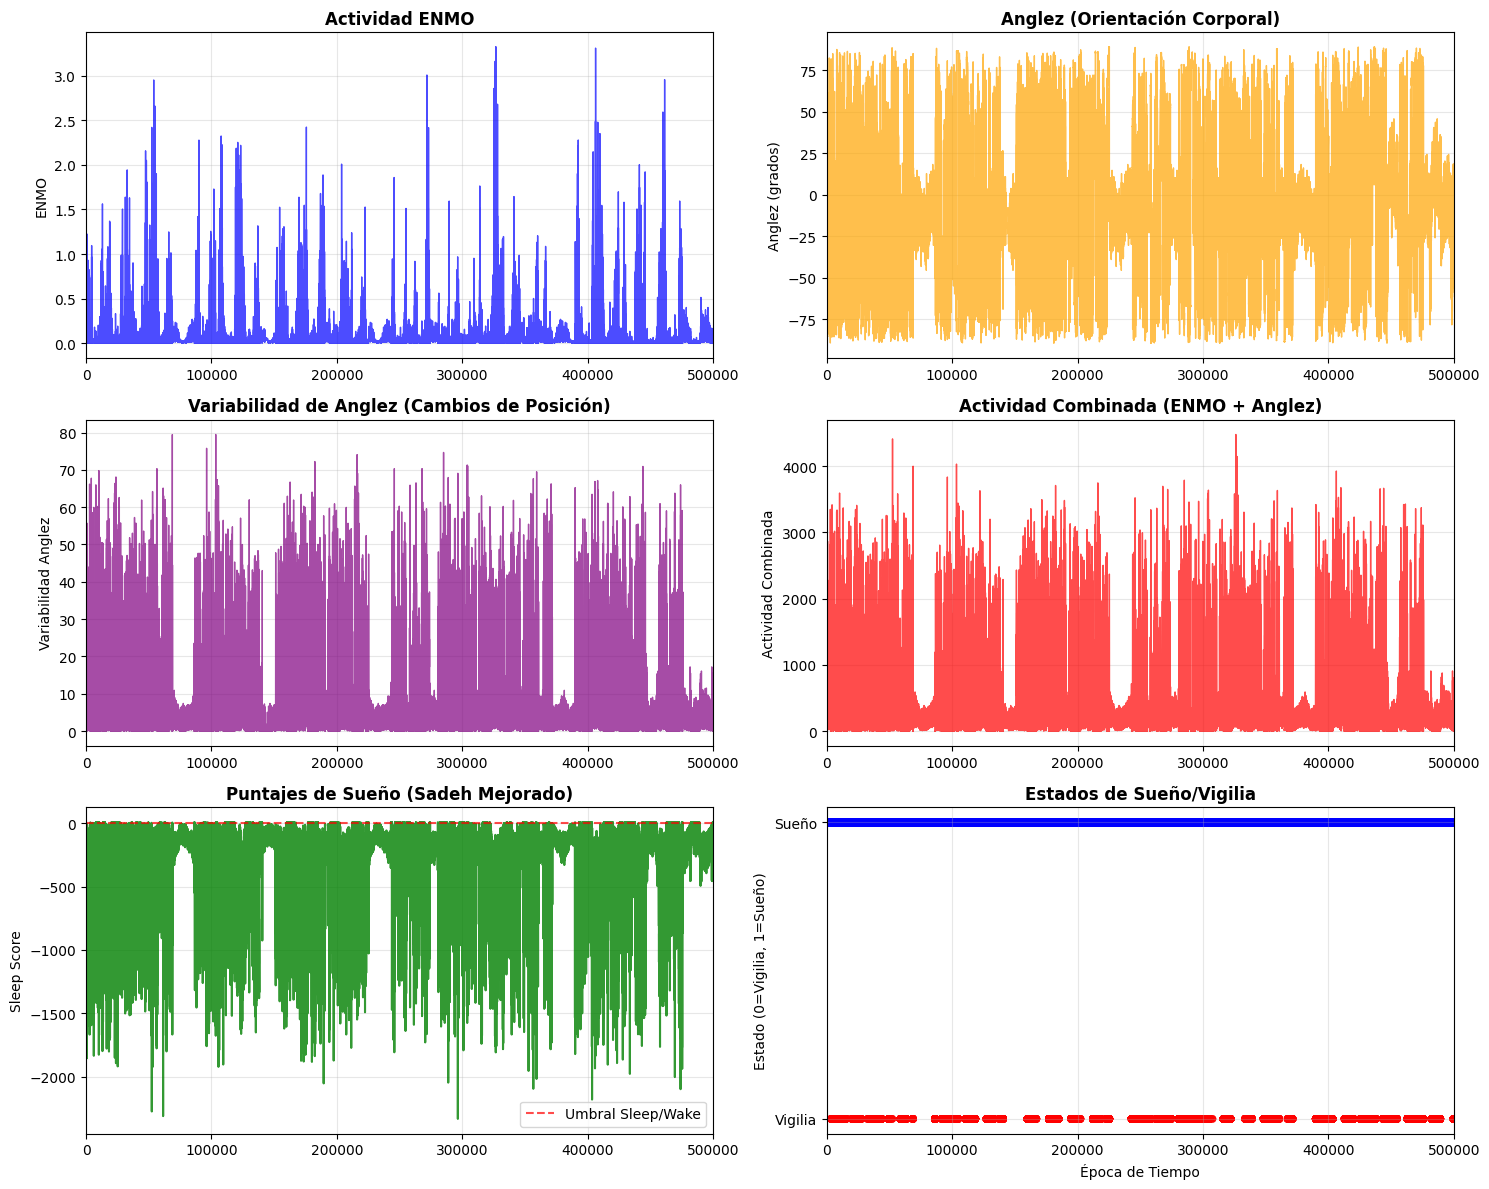

/tmp/ipykernel_10565/3122450860.py:114: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/astroobot/.pyenv/versions/3.11.0/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


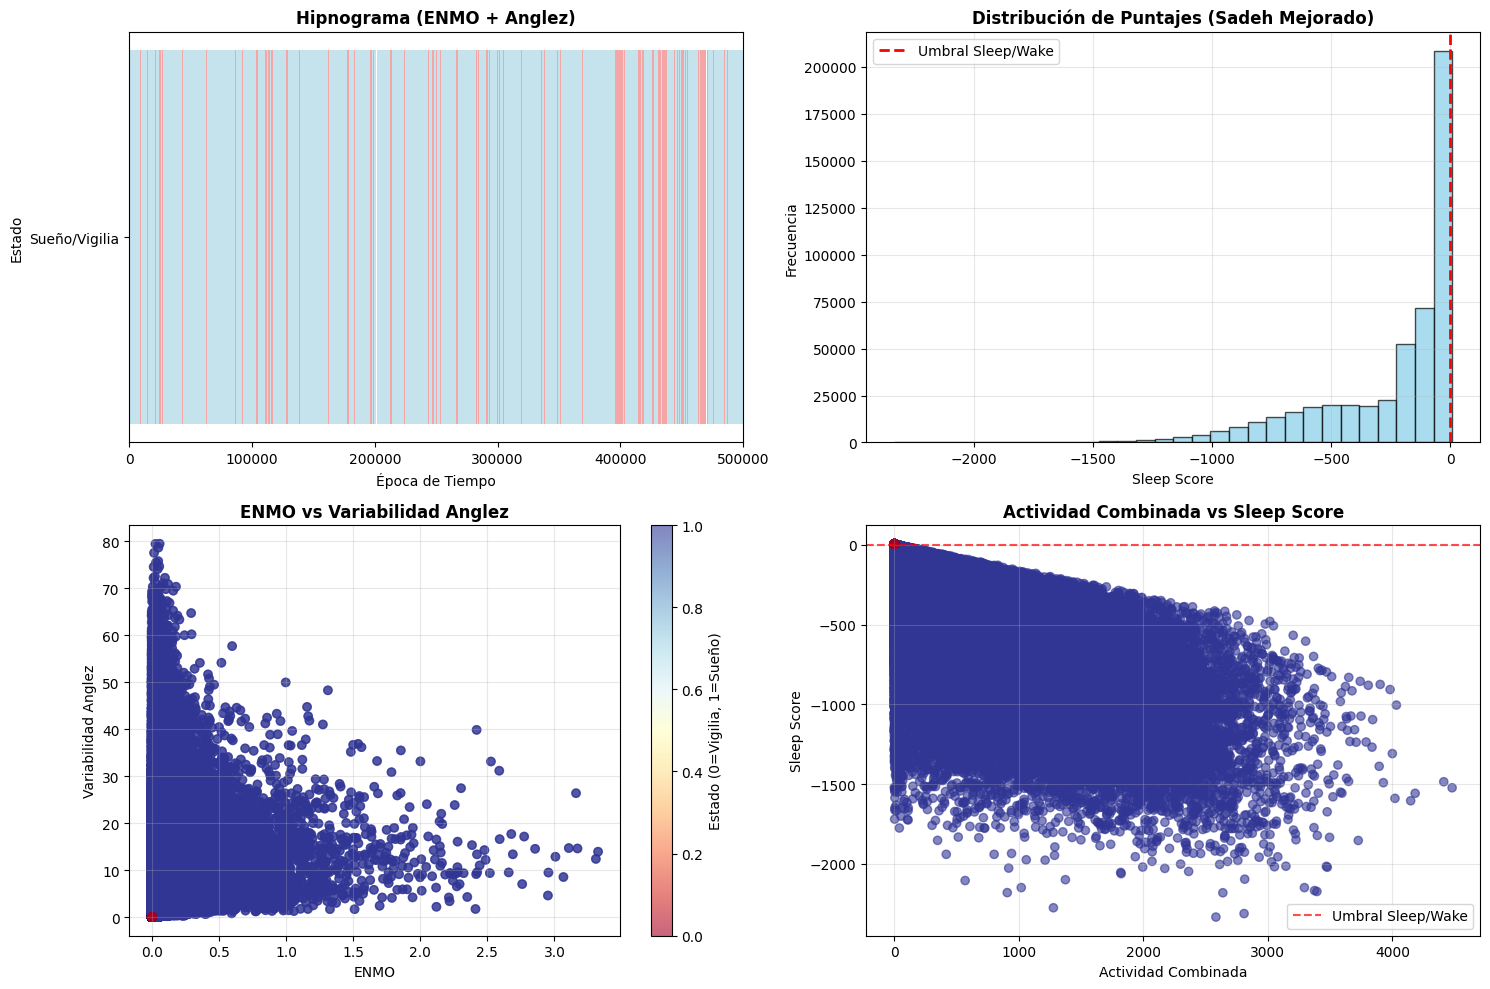


Analisis detallado de transiciones:
   Número de transiciones: 3669
   Fragmentación del sueño: 1834.5 despertares
   Duración promedio período de sueño: 227.0 épocas
   Duración máxima período de sueño: 19371 épocas
   Duración promedio período de vigilia: 45.5 épocas
   Duración máxima período de vigilia: 910 épocas

Ejemplos detallados de puntajes:
   Época 0: ENMO=0.0217, Anglez_var=0.00, Score=-12.33 → Sueño
   Época 100: ENMO=0.0131, Anglez_var=0.05, Score=-7.36 → Sueño
   Época 200: ENMO=0.0134, Anglez_var=0.00, Score=-5.82 → Sueño
   Época 300: ENMO=0.0146, Anglez_var=0.01, Score=-8.72 → Sueño
   Época 400: ENMO=0.0147, Anglez_var=0.06, Score=-11.30 → Sueño
   Época 500: ENMO=0.0149, Anglez_var=0.00, Score=-902.66 → Sueño


In [19]:
# Crear visualización completa de los resultados con ENMO + Anglez
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 12))

# Crear índices de tiempo para el eje x
time_indices = np.arange(len(timestamps))

# 1. Gráfica de ENMO (Actividad)
ax1.plot(time_indices, enmo_values, color='blue', alpha=0.7, linewidth=1)
ax1.set_title('Actividad ENMO', fontsize=12, fontweight='bold')
ax1.set_ylabel('ENMO')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, len(timestamps))

# 2. Gráfica de Anglez (Orientación)
ax2.plot(time_indices, anglez_values, color='orange', alpha=0.7, linewidth=1)
ax2.set_title('Anglez (Orientación Corporal)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Anglez (grados)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, len(timestamps))

# 3. Variabilidad de Anglez
ax3.plot(time_indices, anglez_variability, color='purple', alpha=0.7, linewidth=1)
ax3.set_title('Variabilidad de Anglez (Cambios de Posición)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Variabilidad Anglez')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, len(timestamps))

# 4. Actividad Combinada (ENMO + Anglez)
ax4.plot(time_indices, combined_activity, color='red', alpha=0.7, linewidth=1)
ax4.set_title('Actividad Combinada (ENMO + Anglez)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Actividad Combinada')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, len(timestamps))

# 5. Gráfica de Sleep Scores
ax5.plot(time_indices, sleep_scores, color='green', alpha=0.8, linewidth=1.5)
ax5.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Umbral Sleep/Wake')
ax5.set_title('Puntajes de Sueño (Sadeh Mejorado)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Sleep Score')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, len(timestamps))

# 6. Estados de Sueño/Vigilia
colors = ['red' if state == 0 else 'blue' for state in sleep_states]
ax6.scatter(time_indices, sleep_states, c=colors, alpha=0.6, s=20)
ax6.set_title('Estados de Sueño/Vigilia', fontsize=12, fontweight='bold')
ax6.set_ylabel('Estado (0=Vigilia, 1=Sueño)')
ax6.set_xlabel('Época de Tiempo')
ax6.set_yticks([0, 1])
ax6.set_yticklabels(['Vigilia', 'Sueño'])
ax6.grid(True, alpha=0.3)
ax6.set_xlim(0, len(timestamps))

plt.tight_layout()
plt.show()

# Crear análisis comparativo
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Hipnograma mejorado
sleep_periods = []
current_period_start = None
current_state = None

for i, state in enumerate(sleep_states):
    if current_state != state:
        if current_period_start is not None:
            sleep_periods.append((current_period_start, i-1, current_state))
        current_period_start = i
        current_state = state

if current_period_start is not None:
    sleep_periods.append((current_period_start, len(sleep_states)-1, current_state))

for start, end, state in sleep_periods:
    color = 'lightblue' if state == 1 else 'lightcoral'
    ax1.barh(0, end-start, left=start, height=0.5, color=color, alpha=0.7)

ax1.set_title('Hipnograma (ENMO + Anglez)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época de Tiempo')
ax1.set_ylabel('Estado')
ax1.set_yticks([0])
ax1.set_yticklabels(['Sueño/Vigilia'])
ax1.set_xlim(0, len(timestamps))

# 2. Distribución de puntajes de sueño
ax2.hist(sleep_scores, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Umbral Sleep/Wake')
ax2.set_title('Distribución de Puntajes (Sadeh Mejorado)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sleep Score')
ax2.set_ylabel('Frecuencia')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Correlación ENMO vs Anglez variability
ax3.scatter(enmo_values, anglez_variability, alpha=0.6, c=sleep_states, cmap='RdYlBu')
ax3.set_title('ENMO vs Variabilidad Anglez', fontsize=12, fontweight='bold')
ax3.set_xlabel('ENMO')
ax3.set_ylabel('Variabilidad Anglez')
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(ax3.scatter(enmo_values, anglez_variability, alpha=0.6, c=sleep_states, cmap='RdYlBu'), ax=ax3)
cbar.set_label('Estado (0=Vigilia, 1=Sueño)')

# 4. Actividad vs Sleep Score
ax4.scatter(combined_activity, sleep_scores, alpha=0.6, c=sleep_states, cmap='RdYlBu')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Umbral Sleep/Wake')
ax4.set_title('Actividad Combinada vs Sleep Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('Actividad Combinada')
ax4.set_ylabel('Sleep Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular transiciones y estadísticas mejoradas
transitions = []
for i in range(1, len(sleep_states)):
    if sleep_states[i] != sleep_states[i-1]:
        transitions.append(i)

print(f"\nAnalisis detallado de transiciones:")
print(f"   Número de transiciones: {len(transitions)}")
print(f"   Fragmentación del sueño: {len(transitions)/2:.1f} despertares")

# Análisis de períodos
sleep_period_lengths = []
wake_period_lengths = []

for start, end, state in sleep_periods:
    period_length = end - start + 1
    if state == 1:  # Sleep
        sleep_period_lengths.append(period_length)
    else:  # Wake
        wake_period_lengths.append(period_length)

if sleep_period_lengths:
    print(f"   Duración promedio período de sueño: {np.mean(sleep_period_lengths):.1f} épocas")
    print(f"   Duración máxima período de sueño: {np.max(sleep_period_lengths)} épocas")

if wake_period_lengths:
    print(f"   Duración promedio período de vigilia: {np.mean(wake_period_lengths):.1f} épocas")
    print(f"   Duración máxima período de vigilia: {np.max(wake_period_lengths)} épocas")

# Mostrar algunos ejemplos de puntajes con componentes
print(f"\nEjemplos detallados de puntajes:")
for i in [0, 100, 200, 300, 400, 500]:
    if i < len(sleep_scores):
        state_text = "Sueño" if sleep_states[i] == 1 else "Vigilia"
        print(f"   Época {i}: ENMO={enmo_values[i]:.4f}, Anglez_var={anglez_variability[i]:.2f}, Score={sleep_scores[i]:.2f} → {state_text}")